In [9]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os


In [10]:
load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [11]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY
)


In [12]:
# create state 

class BlogState(TypedDict):

    title : str
    content: str
    outline: str

In [13]:
def create_outline(state: BlogState) -> BlogState:
    
    # fetch title
    title = state['title']

    # form a prompt
    prompt = f'Generate a detailed outline for a blog on the topic \n {title}'

    # ask that question to llm
    outline = model.invoke(prompt).content

    # update the outline in the state
    state['outline'] = outline

    return state



In [14]:
def create_blog(state: BlogState) -> BlogState:
    
    # fetch title and outline
    title = state['title']
    outline = state['outline']


    # form a prompt
    prompt = f'write a detailed blog on the title - \n {title} using the following outline \n {outline}'

    # ask that question to llm
    content = model.invoke(prompt).content

    # update the content in the state
    state['content'] = content

    return state

In [15]:
# create our graph

graph = StateGraph(BlogState)

# add nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)


# add edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog', END)


# compile the graph
workflow = graph.compile()

In [16]:
# execute the graph
initial_state = {'title':'Rise of AI in pakistan?'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Rise of AI in pakistan?', 'content': "# The AI Awakening: Pakistan's Journey into the Future of Artificial Intelligence\n\nArtificial Intelligence (AI) is no longer a futuristic concept; it's a present-day reality rapidly reshaping economies and societies worldwide. From powering recommendation engines to optimizing supply chains and advancing medical diagnostics, AI's transformative power is undeniable. While often associated with Silicon Valley or advanced European nations, a quiet yet significant AI revolution is unfolding in an unexpected corner: **Pakistan**.\n\nAt its core, AI refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. This encompasses various sub-fields like machine learning (where systems learn from data without explicit programming) and deep learning (which uses neural networks to process complex patterns). Pakistan is at a pivotal juncture, embracing AI to drive innovation, economic growth, and pro

In [18]:
print(final_state['content'])
print(final_state['outline'])

# The AI Awakening: Pakistan's Journey into the Future of Artificial Intelligence

Artificial Intelligence (AI) is no longer a futuristic concept; it's a present-day reality rapidly reshaping economies and societies worldwide. From powering recommendation engines to optimizing supply chains and advancing medical diagnostics, AI's transformative power is undeniable. While often associated with Silicon Valley or advanced European nations, a quiet yet significant AI revolution is unfolding in an unexpected corner: **Pakistan**.

At its core, AI refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. This encompasses various sub-fields like machine learning (where systems learn from data without explicit programming) and deep learning (which uses neural networks to process complex patterns). Pakistan is at a pivotal juncture, embracing AI to drive innovation, economic growth, and problem-solving, despite facing unique challenges. This 

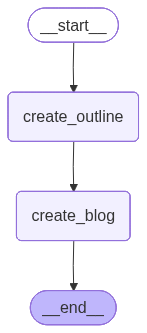

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())